# Reconstruction with Different Measurement Operators

This notebook runs **CS-ROMER reconstruction** on the **same dataset** with three measurement operators (full resolution, λ²₀ = 0):

- **direct**: NDFT (direct Fourier, non-uniform λ²)
- **nufft**: Non-uniform FFT with Kaiser interpolation
- **gridded**: Grid data onto uniform λ² then FFT

We compare recovered model and restored spectra to check consistency.

In [1]:
import copy
import numpy as np
import matplotlib.pyplot as plt

from csromer.simulation import FaradayThinSource
from csromer.pipelines.simulation import run_simulation, SimulateStep, ApplyNoiseStep
from csromer.pipelines.reconstruction import (
    CSROMERReconstructorWrapper,
    make_cg_optimizer,
)
from csromer.utils.array_utils import asnumpy

plt.rcParams['figure.figsize'] = (14, 8)
%matplotlib inline

## 1. Create one dataset (full resolution)

Single thin source; we will run three reconstructions with different `measurement_operator_kind`.

In [2]:
nu = np.linspace(1.0e9, 1.5e9, 128)
source = FaradayThinSource(nu=nu, s_nu=0.1, phi_gal=50.0, spectral_idx=-0.7)
run_simulation(source, [
    SimulateStep(),
    ApplyNoiseStep(0.01, random_state=np.random.RandomState(42)),
])
source.l2_ref = 0.0  # full resolution
print(f"Dataset: {len(nu)} channels, λ²₀ = {source.l2_ref} (full resolution)")

Dataset: 128 channels, λ²₀ = 0.0 (full resolution)


## 2. Run reconstruction with direct, nufft, and gridded

Same data, same CG settings; only `measurement_operator_kind` changes. For "gridded" the pipeline replaces the dataset with the gridded version internally.

In [3]:
kinds = ["direct", "nufft", "gridded"]
recons = {}
for kind in kinds:
    # Each reconstructor gets a copy so gridded can replace dataset without affecting others
    data = copy.deepcopy(source)
    recon = CSROMERReconstructorWrapper(
        dataset=data,
        oversampling=4.0,
        measurement_operator_kind=kind,
        optimizer_factory=make_cg_optimizer(maxiter=50, tol=1e-10, verbose=False),
    )
    recon.reconstruct()
    recons[kind] = recon
    print(f"{kind}: model RM = {recon.rm_model:.3f} rad/m², restored RM = {recon.rm_restored:.3f} rad/m²")

FWHM of the main peak of the RMTF: 15.406 rad/m^2
Maximum recovered width structure: 78.649 rad/m^2
Maximum Faraday Depth to which one has more than 50% sensitivity: 4405.503
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve] kernel len=15 sum=4.228633 max=1.000000 (peak=1)
Convolving with Gaussian kernel where FWHM 15.406 rad/m^2 - sigma 6.542 rad/m^2 - sigma_pixels 1.6870
  [convolve] kernel len=15 sum=4.228633 max=1.000000 (peak=1)
[restore DEBUG]
  cellsize=3.878084  rmtf_fwhm=15.405926  pixels_per_rmtf=3.9726
  peak:  dirty=9.976275e-02  model=6.314112e-03  residual=6.429778e-05
  peak:  conv_model(Jy/phi)=1.837528e-02  conv*ppr(Jy/rmtf)=1.837528e-02  restored=1.837704e-02
  sum|model|=3.871080e-01  sum|conv_model|=1.111149e+00
  ratio dirty_peak/model_peak=15.8000  (expect ~pixels_per_rmtf=3.9726)
  theo_noise (chan)=8.838835e-04
  fd-space: mad_std(fd_residual)=9.716419e-06  rms(|fd_residual|)=1.414121e-05  rms(|fd_

## 3. Compare model and restored spectra

All three operators should recover the same peak location. **Small differences in peak amplitude are expected.**

**Why is the gridded model peak lower?**

- **Direct (NDFT)** uses the actual non-uniform λ² sampling; it is the reference for flux and resolution.
- **NUFFT** approximates the transform with a kernel (e.g. Kaiser); normalization is tuned so the dirty spectrum matches direct.
- **Gridded** first bins the data onto a uniform λ² grid (each bin = weighted average of channels in that λ² interval). That binning is equivalent to **convolving** the sampling pattern (and the data) with a **box function** in λ² of width Δλ². In Faraday depth (φ) space, convolution in λ² becomes multiplication by the Fourier transform of the box—a **sinc**—so the effective response (point-spread) is the original RMTF × sinc. That **widens** the effective beam and **lowers the peak** (integrated flux is preserved, but the same flux is spread over more φ). So the optimizer recovers a model whose peak is lower when the “beam” is effectively wider. This is expected; the **restored** map (convolved model + residual) is in consistent units (Jy/rmtf) and is what you use for flux comparison.

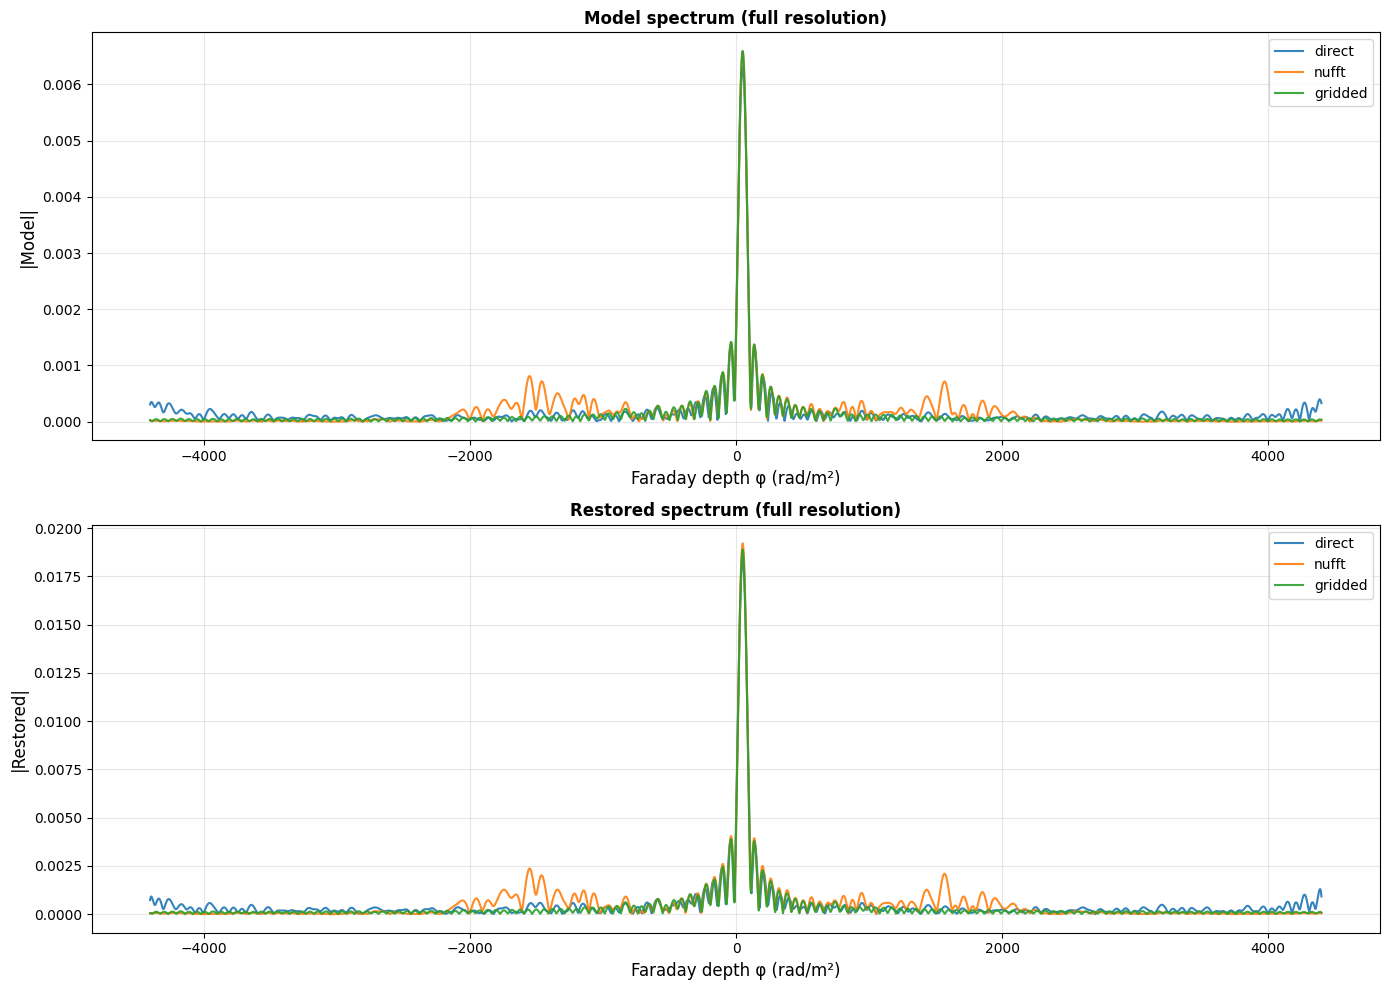

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for kind in kinds:
    r = recons[kind]
    phi = np.asarray(asnumpy(r.parameter.phi))
    ax = axes[0]
    ax.plot(phi, np.abs(np.asarray(asnumpy(r.fd_model))), label=kind, alpha=0.9)
    ax = axes[1]
    ax.plot(phi, np.abs(np.asarray(asnumpy(r.fd_restored))), label=kind, alpha=0.9)

axes[0].set_xlabel('Faraday depth φ (rad/m²)', fontsize=12)
axes[0].set_ylabel('|Model|', fontsize=12)
axes[0].set_title('Model spectrum (full resolution)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Faraday depth φ (rad/m²)', fontsize=12)
axes[1].set_ylabel('|Restored|', fontsize=12)
axes[1].set_title('Restored spectrum (full resolution)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()